# **IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs)**

# **For Image Classification**




     24BAD013
     Arunagiri R



**IMPORT LIBRARIES**

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report


print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# **PART A: DATASET PREPARATION**

In [27]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 class names
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Original Training Data:", x_train.shape)
print("Original Testing Data :", x_test.shape)

Original Training Data: (50000, 32, 32, 3)
Original Testing Data : (10000, 32, 32, 3)


**PREPROCESSING**

In [28]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

**TRAIN - VALIDATION SPLIT**

In [29]:
validation_size = 5000

x_val = x_train[-validation_size:]
y_val = y_train[-validation_size:]

x_train = x_train[:-validation_size]
y_train = y_train[:-validation_size]

print("Training Data  :", x_train.shape)
print("Validation Data:", x_val.shape)
print("Testing Data   :", x_test.shape)


Training Data  : (45000, 32, 32, 3)
Validation Data: (5000, 32, 32, 3)
Testing Data   : (10000, 32, 32, 3)


**DISPLAY SAMPLE IMAGES**

/tmp/ipykernel_2002/2217893887.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


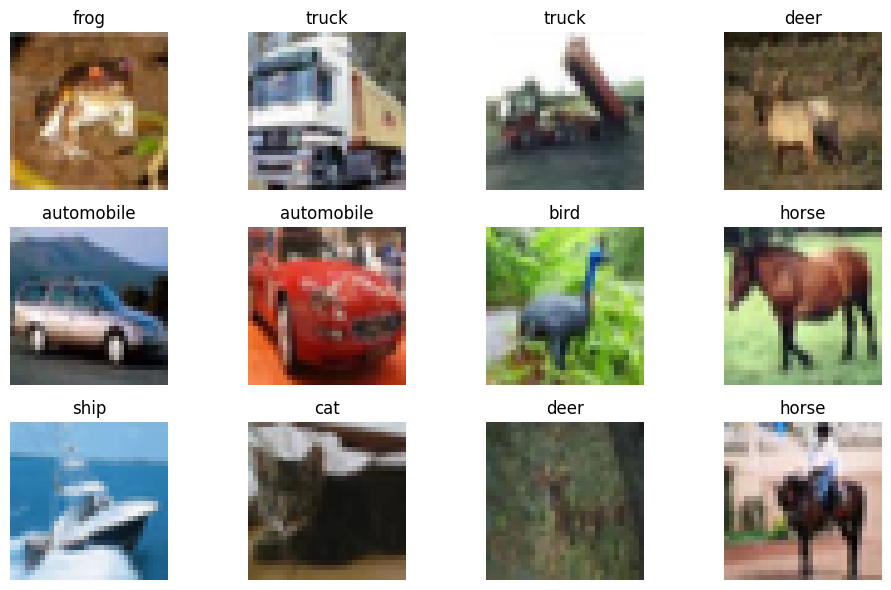

In [30]:

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_train[i])

    plt.title(class_names[int(y_train[i])])

    plt.axis("off")

plt.tight_layout()
plt.show()

# **PART B: CNN MODEL IMPLEMENTATION**

**Convolution Block 1**

In [31]:
# Convolution Block 1

model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2))
])

**Convolution Block 2**

In [32]:
model = models.Sequential([

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2))

])

**Convolution Block 3**

In [33]:
# Convolution Block 3

layers.Conv2D(
    128,
    (3, 3),
    activation="relu",
    padding="same"
),

layers.MaxPooling2D((2, 2)),

# Fully Connected Layer
layers.Flatten(),

layers.Dense(
    128,
    activation="relu"
),

# Dropout
layers.Dropout(0.5),

# Output Layer - Softmax
layers.Dense(
    10,
    activation="softmax"
)

<Dense name=dense_5, built=False>

**COMPILE MODEL**

In [34]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


# **PART C: MODEL TRAINING**

In [41]:

model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])


# =========================
# COMPILE
# =========================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


model.summary()


# =========================
# TRAIN
# =========================

history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=2,
    validation_data=(x_val, y_val),
    verbose=1
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 155ms/step - accuracy: 0.3680 - loss: 1.7055 - val_accuracy: 0.4998 - val_loss: 1.4001
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 156ms/step - accuracy: 0.5188 - loss: 1.3359 - val_accuracy: 0.5666 - val_loss: 1.1939


**TESTING**

In [42]:

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Loss     :", test_loss)

print(
    "Test Accuracy :",
    test_accuracy * 100,
    "%"
)



Test Loss     : 1.2041903734207153
Test Accuracy : 56.550002098083496 %


**ACCURACY VS EPOCH**

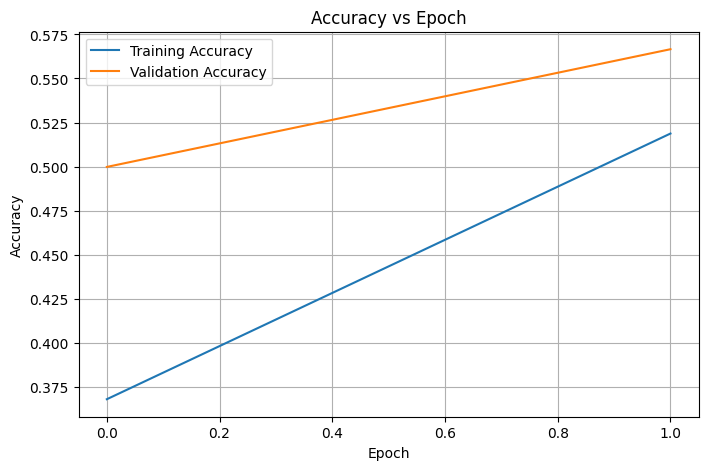

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid()

plt.show()

**LOSS VS EPOCH**

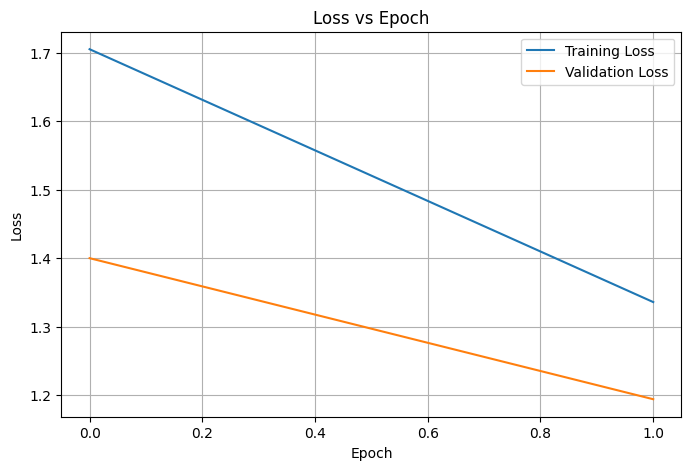

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.grid()

plt.show()


# **PART D: PERFORMANCE ANALYSIS**

In [45]:
y_probability = model.predict(
    x_test,
    verbose=0
)

# Convert probability to class number
y_pred = np.argmax(
    y_probability,
    axis=1
)

y_true = y_test.flatten()

**CLASSIFICATION REPORT**

In [46]:

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Classification Report:

              precision    recall  f1-score   support

    airplane       0.62      0.60      0.61      1000
  automobile       0.75      0.74      0.74      1000
        bird       0.45      0.40      0.42      1000
         cat       0.42      0.28      0.33      1000
        deer       0.53      0.36      0.43      1000
         dog       0.64      0.28      0.38      1000
        frog       0.41      0.90      0.56      1000
       horse       0.68      0.65      0.67      1000
        ship       0.60      0.84      0.70      1000
       truck       0.72      0.62      0.67      1000

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.55     10000
weighted avg       0.58      0.57      0.55     10000



**CONFUSION MATRIX**

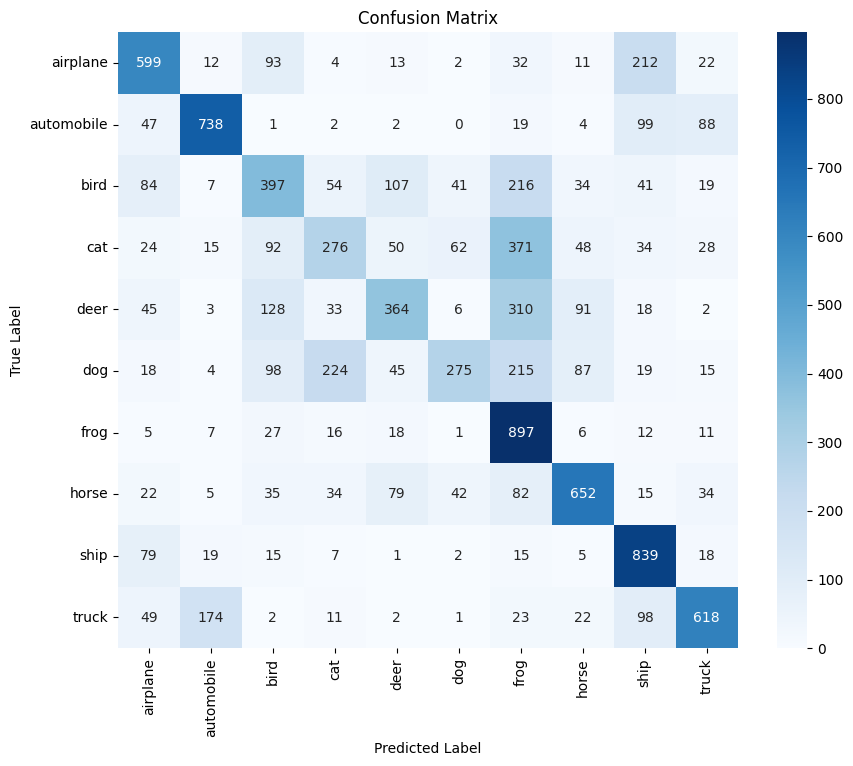

In [47]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",

    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

**SAMPLE PREDICTIONS**

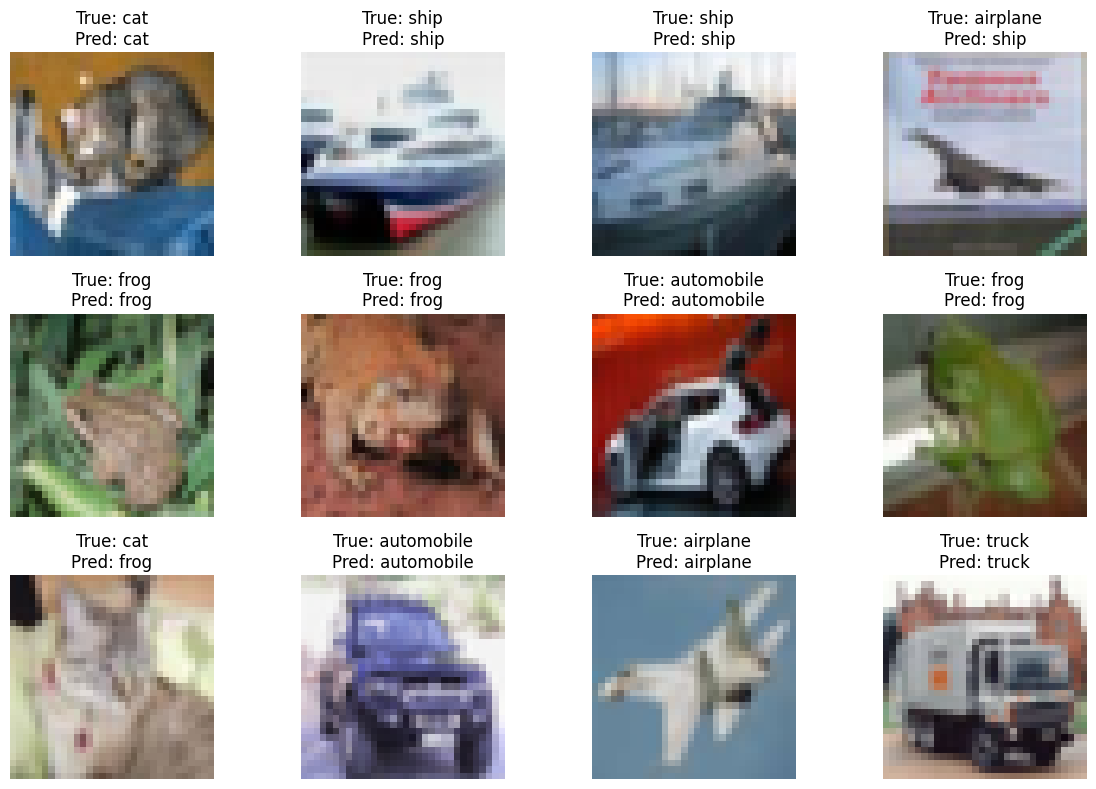

In [48]:
plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    true_label = class_names[y_true[i]]

    predicted_label = class_names[y_pred[i]]

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

**MISCLASSIFIED IMAGES**

Total Misclassified Images: 4345


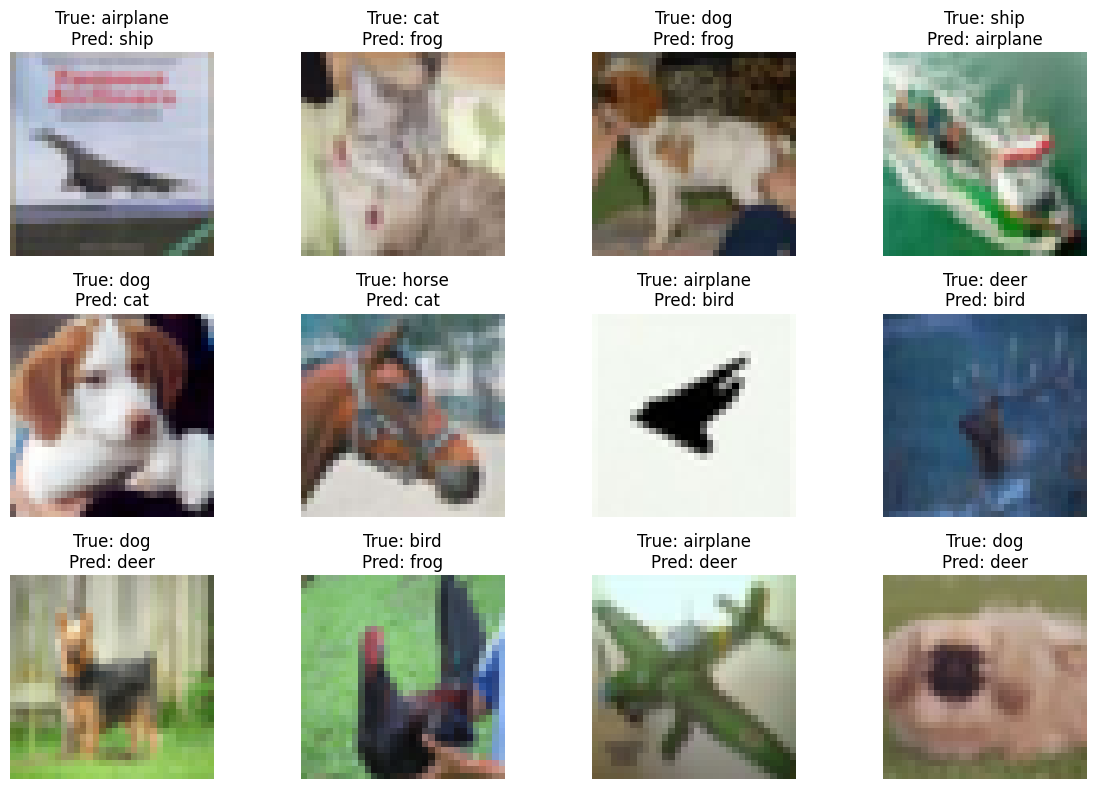

In [49]:
wrong_indices = np.where(
    y_pred != y_true
)[0]

print(
    "Total Misclassified Images:",
    len(wrong_indices)
)


plt.figure(figsize=(12, 8))

for j, index in enumerate(
    wrong_indices[:12]
):

    plt.subplot(3, 4, j + 1)

    plt.imshow(x_test[index])

    true_label = class_names[y_true[index]]

    predicted_label = class_names[y_pred[index]]

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

**FINAL RESULT**

In [50]:
print("\n====================================")
print("          FINAL RESULT")
print("====================================")

print(
    f"Training Accuracy : "
    f"{history.history['accuracy'][-1] * 100:.2f}%"
)

print(
    f"Validation Accuracy : "
    f"{history.history['val_accuracy'][-1] * 100:.2f}%"
)

print(
    f"Testing Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

print("====================================")


          FINAL RESULT
Training Accuracy : 51.88%
Validation Accuracy : 56.66%
Testing Accuracy : 56.55%
